In [8]:
import argparse, time, os
import random
from sklearn.cluster import DBSCAN
from localtileserver.tiler import get_point
from tqdm import tqdm
import copy, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from pyproj import Proj, Transformer, Geod
import hvplot.pandas
import panel as pn
%matplotlib widget

In [9]:
bedmap_folder = f"/media/maffe/nvme/polar_ice_thickness_data/bedmap"

# Find all .csv files in the directory
files_bedmap = [
    os.path.join(root, file)
    for root, _, files in os.walk(bedmap_folder)
    for file in files if file.endswith(".csv")
]

# Process each file
total_files = len(files_bedmap)
print(f"We are dealing with {total_files} files from BedMap")

We are dealing with 151 files from BedMap


In [57]:
path1 = '/media/maffe/nvme/polar_ice_thickness_data/bedmap/bedmap/bedmap2/BEDMAP2_-_Ice_thickness__bed_and_surface_elevation_for_Antarctica_-_standardised_data_points/BEDMAP2 - Ice thickness, bed and surface elevation for Antarctica - standardised data points/'
#path1 = '/media/maffe/nvme/polar_ice_thickness_data/bedmap/bedmap/bedmap3/'
file1 = 'NIPR_2007_JARE49_GRN_BM2.csv'

#path2 = '/media/maffe/nvme/polar_ice_thickness_data/bedmap/bedmap/bedmap2/BEDMAP2_-_Ice_thickness__bed_and_surface_elevation_for_Antarctica_-_standardised_data_points/BEDMAP2 - Ice thickness, bed and surface elevation for Antarctica - standardised data points/'
path2 = '/media/maffe/nvme/polar_ice_thickness_data/bedmap/bedmap/bedmap3/'
file2 = 'NIPR_2007_JARE49_GRN_BM3.csv'

path3 = '/media/maffe/nvme/polar_ice_thickness_data/bedmap/bedmap/bedmap3/'
file3 = 'INGV_1999_Talos-Dome_AIR_BM3.csv'



In [58]:
df_file1_csv = pd.read_csv(path1+file1, skiprows=18, low_memory=False)
df_file2_csv = pd.read_csv(path2+file2, skiprows=18, low_memory=False)
df_file3_csv = pd.read_csv(path3+file3, skiprows=18, low_memory=False)
df_file2_csv = df_file2_csv.loc[df_file2_csv['land_ice_thickness (m)']>0]
print(f"File 1: {len(df_file1_csv)}")
print(f"File 2: {len(df_file2_csv)}")
print(f"File 3: {len(df_file3_csv)}")

File 1: 6745
File 2: 13892
File 3: 1470980


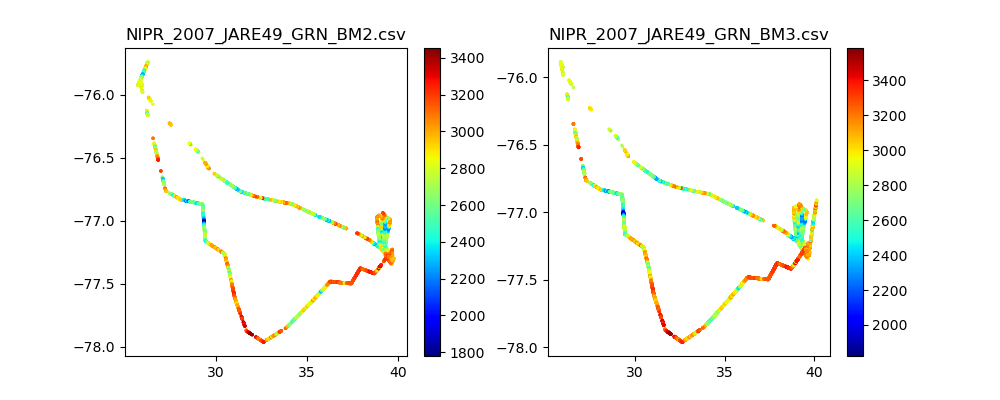

In [59]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
s1 = ax1.scatter(x=df_file1_csv['longitude (degree_east)'], y=df_file1_csv['latitude (degree_north)'],
           c=df_file1_csv['land_ice_thickness (m)'], cmap='jet', s=2) # 
s2 = ax2.scatter(x=df_file2_csv['longitude (degree_east)'], y=df_file2_csv['latitude (degree_north)'],
           c=df_file2_csv['land_ice_thickness (m)'], cmap='jet', s=2) # 
#s3 = ax3.scatter(x=df_file3_csv['longitude (degree_east)'], y=df_file3_csv['latitude (degree_north)'],
#           c=df_file3_csv['land_ice_thickness (m)'], cmap='jet', s=2) # 

cb1 = plt.colorbar(s1)
cb2 = plt.colorbar(s2)
#cb3 = plt.colorbar(s3)

ax1.set_title(file1)
ax2.set_title(file2)
#ax3.set_title(file3)

#for ax in (ax1, ax2, ax3):
#    ax.set_xlim(110, 170)
#    ax.set_ylim(-78, -68.5)

plt.show()
